# Motorcars

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline


## Laden

In [3]:
df = pd.read_csv('./mtcars.csv')

## Exploration

In [4]:
df.shape

(32, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   model   32 non-null     object 
 1   mpg     32 non-null     float64
 2   cyl     32 non-null     int64  
 3   disp    32 non-null     float64
 4   hp      32 non-null     int64  
 5   drat    32 non-null     float64
 6   wt      32 non-null     float64
 7   qsec    32 non-null     float64
 8   vs      32 non-null     int64  
 9   am      32 non-null     int64  
 10  gear    32 non-null     int64  
 11  carb    32 non-null     int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 3.1+ KB


* Bedeutung der Spalten
  * model = Name
  * mpg = Miles per Gallon
  * cyl = Anzahl der Zylinder
  * displacement = Hubraum
  * hp = PS
  * drat = Achsenübersetzung
  * wt = Gewicht
  * qsec = "Quarter Mile Time"
  * vs = Motortyp, 0=V-Shaped, 1 = normal
  * am = Gangschaltung, 0=automatisch, 1=manuell
  * gear = Anzahl Gänge ohne Rückwärtsgang
  * carb = Anzahl der Vergaser (= carburetors)

* Ergebnis
  * Fast alles numerisch
  * Kandidaten Kategorien
    * cyl, vs, am und gear
    * Model

In [6]:
df['model'].nunique()

32

* model ist nicht sinnvoll kategorisierbar, hat ja soviele Werte wie der gesamte Datensatz

In [7]:
category_candidates = ('cyl', 'vs', 'am', 'gear', 'carb')
for column in category_candidates:
    print(f'{column} has {df[column].nunique()} values')


cyl has 3 values
vs has 2 values
am has 2 values
gear has 3 values
carb has 6 values


* Ergebnis
  * cyl, vs, am, gear, carb sind kategorisierbar
  

In [8]:
for column in category_candidates:
    df[column] = pd.Categorical(df[column])
df.info()    

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   model   32 non-null     object  
 1   mpg     32 non-null     float64 
 2   cyl     32 non-null     category
 3   disp    32 non-null     float64 
 4   hp      32 non-null     int64   
 5   drat    32 non-null     float64 
 6   wt      32 non-null     float64 
 7   qsec    32 non-null     float64 
 8   vs      32 non-null     category
 9   am      32 non-null     category
 10  gear    32 non-null     category
 11  carb    32 non-null     category
dtypes: category(5), float64(5), int64(1), object(1)
memory usage: 2.8+ KB


* Verteilung der Daten

<Axes: >

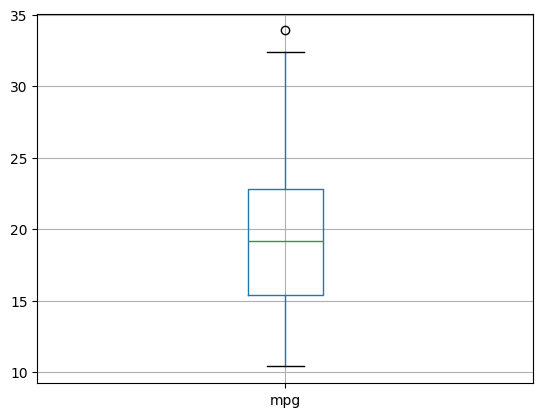

In [9]:
df.boxplot('mpg')

<Axes: title={'center': 'mpg'}, xlabel='cyl'>

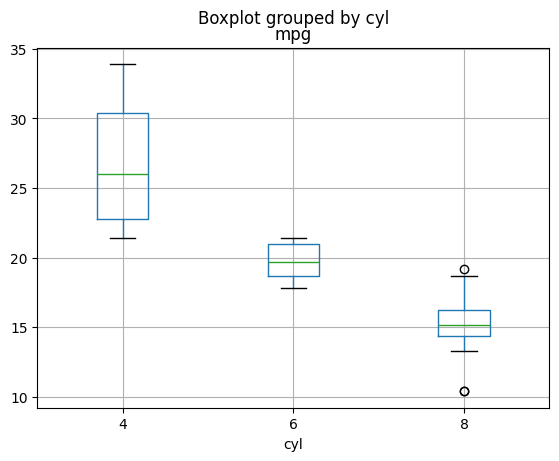

In [10]:
df.boxplot('mpg', by='cyl')

<Axes: title={'center': 'hp'}, xlabel='cyl'>

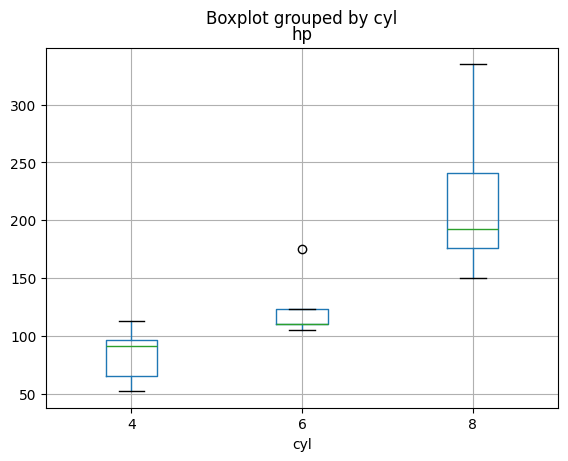

In [11]:
df.boxplot('hp', by='cyl')

<Axes: title={'center': 'wt'}, xlabel='cyl'>

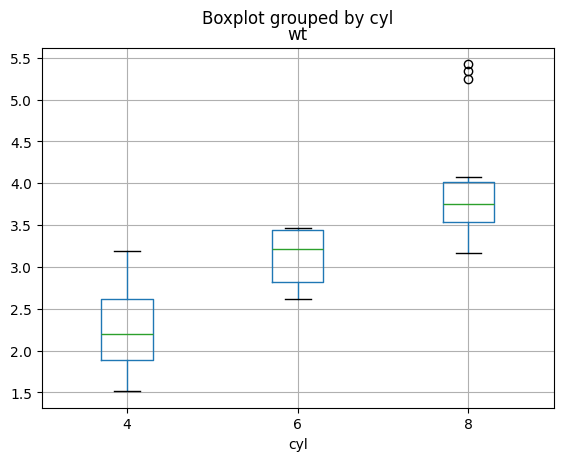

In [12]:
df.boxplot('wt', by='cyl')

array([[<Axes: title={'center': 'mpg'}>]], dtype=object)

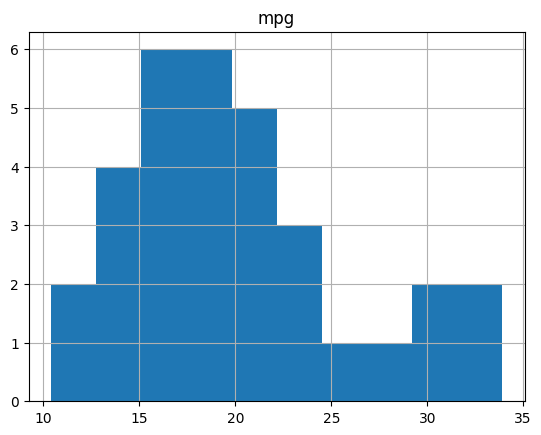

In [13]:
df.hist('mpg')

C:\Users\raine\AppData\Local\Temp\ipykernel_20416\1610424952.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.hist('mpg', 'cyl')


array([[<Axes: title={'center': '4'}>, <Axes: title={'center': '6'}>],
       [<Axes: title={'center': '8'}>, <Axes: >]], dtype=object)

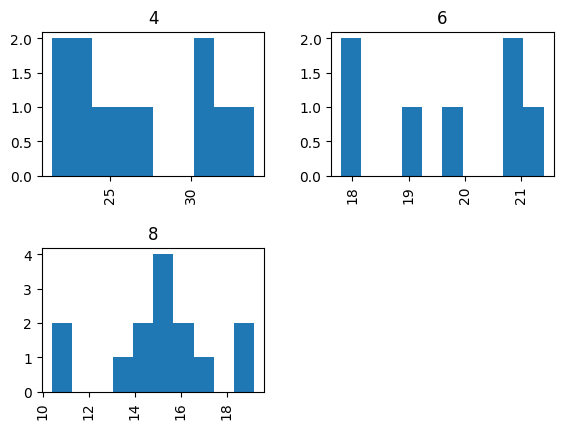

In [14]:
df.hist('mpg', 'cyl')

### Schauen wir uns potenziellen Zusammenhänge an:

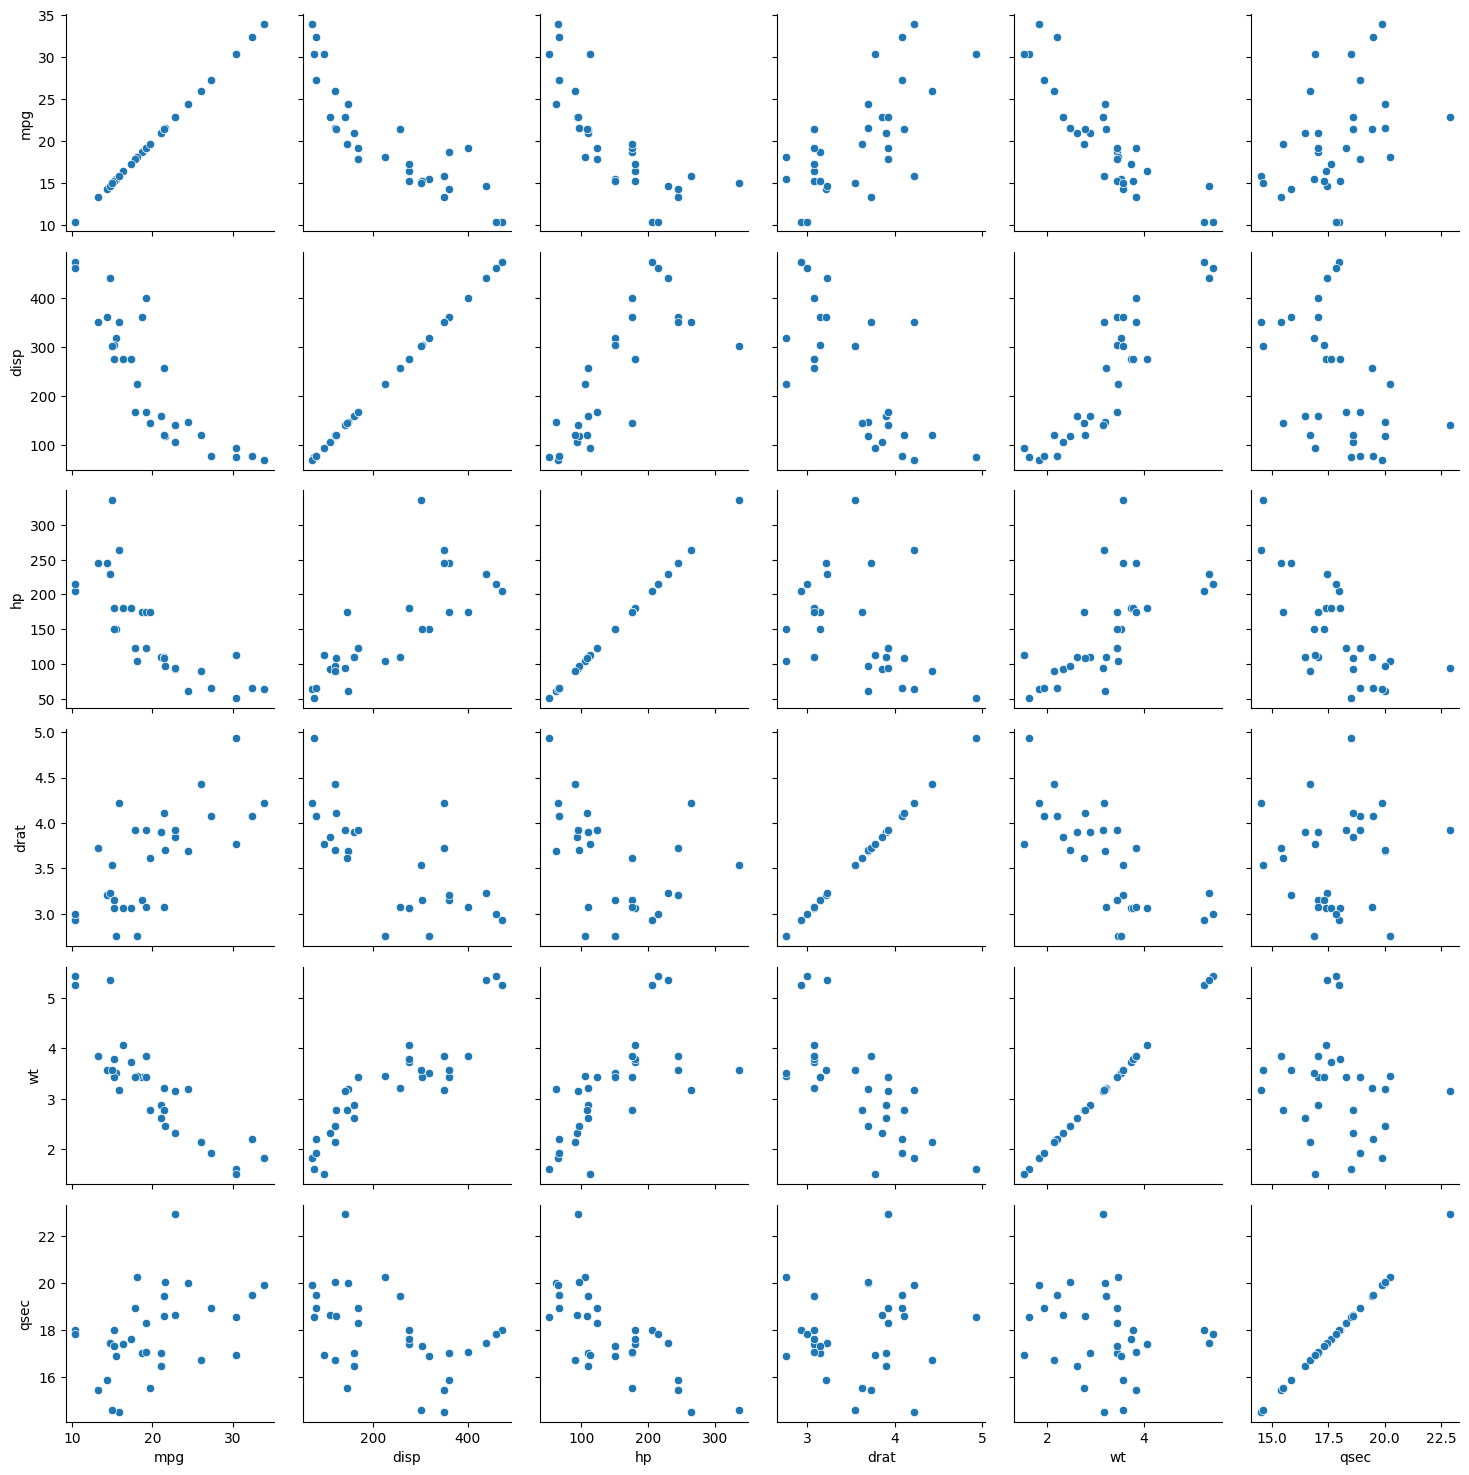

In [15]:
plots = sns.PairGrid(df)
plots.map(sns.scatterplot)

* oder als Heatmap

<Axes: >

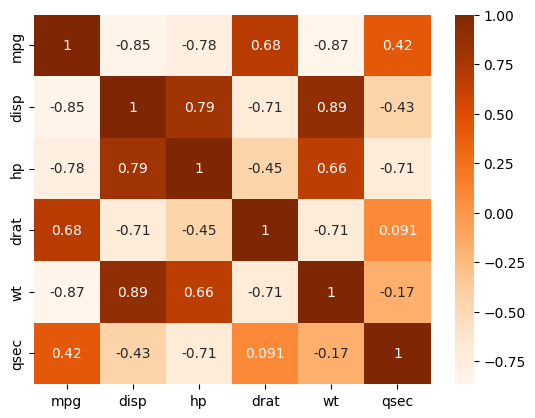

In [36]:
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='Oranges')

## Analyse

### Deskriptive Statistik

* Übersicht

In [17]:
df.describe()

,mpg,disp,hp,drat,wt,qsec
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,20.090625,230.721875,146.687500,3.596563,3.217250,17.848750
std,6.026948,123.938694,68.562868,0.534679,0.978457,1.786943
min,10.400000,71.100000,52.000000,2.760000,1.513000,14.500000
25%,15.425000,120.825000,96.500000,3.080000,2.581250,16.892500
50%,19.200000,196.300000,123.000000,3.695000,3.325000,17.710000
75%,22.800000,326.000000,180.000000,3.920000,3.610000,18.900000
max,33.900000,472.000000,335.000000,4.930000,5.424000,22.900000


* Skewness
  * Wie schief sind die Daten im Vergleich zu einer Normalverteilung
  * bzw. gibt es Schultern, mehrere Maxima 

In [18]:
df['mpg'].skew()

np.float64(0.6723771376290805)

* Kurtosis
  * "Wölbung" im Vergleich zu einer Normalverteilung
  * ist die Verteilung enger oder weiter?

In [19]:
df['mpg'].kurt()

np.float64(-0.0220062914240855)

* Darstellung im Density-Plot
  * Ein Density Plot ist eine Abart eines Histogramms, das vereinfacht unendlich viele bins hat und zusätzlich noch eine Mittelung vornimmt, um Zacken zu vermeiden

<Axes: ylabel='Density'>

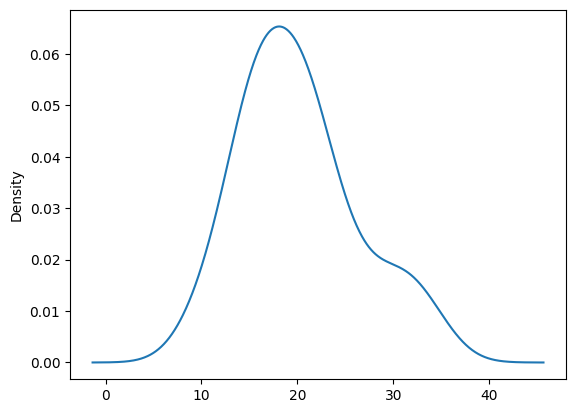

In [20]:
df['mpg'].plot(kind='density')

* wt und hp

In [42]:
print(f'Skewness weight: {df['wt'].skew()}')
print(f'Kurtosis weight: {df['wt'].kurt()}')
print(f'Skewness horsepower: {df['hp'].skew()}')
print(f'Kurtosis horsepower: {df['hp'].kurt()}')

Skewness weight: 0.4659161067929858
Kurtosis weight: 0.416594669634927
Skewness horsepower: 0.7994066925956381
Kurtosis horsepower: 0.2752115875371124


<Axes: ylabel='Density'>

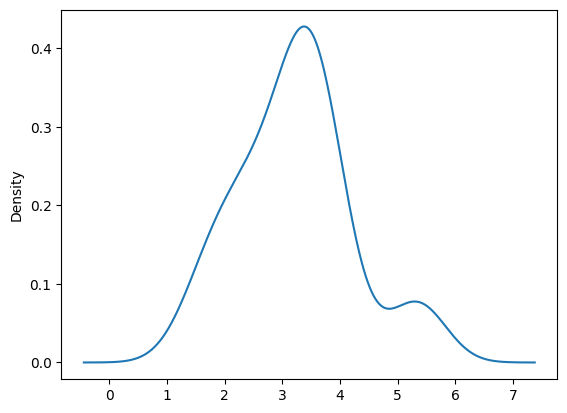

In [38]:
df['wt'].plot(kind='density')

<Axes: ylabel='Density'>

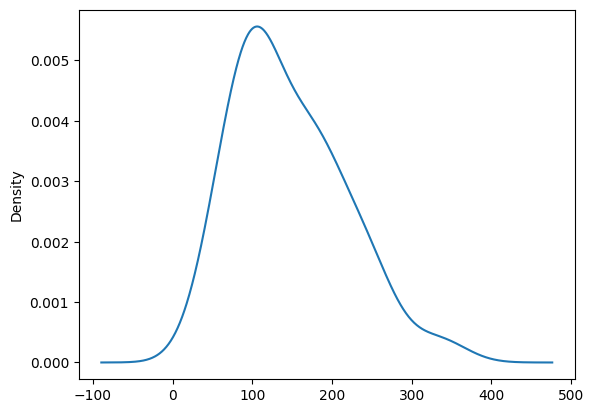

In [41]:
df['hp'].plot(kind='density')